In [1]:
import os
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEMENTE_GLOBAL = 42

random.seed(SEMENTE_GLOBAL)
np.random.seed(SEMENTE_GLOBAL)
os.environ['PYTHONHASHSEED'] = str(SEMENTE_GLOBAL)

torch.manual_seed(SEMENTE_GLOBAL)
torch.cuda.manual_seed(SEMENTE_GLOBAL)
torch.cuda.manual_seed_all(SEMENTE_GLOBAL)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

CAMINHO_DATASET = "/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset"
TAMANHO_IMAGEM = 512

print(f"Rodando na: {device}")
print(f"Sementes globais fixadas em {SEMENTE_GLOBAL} para reprodutibilidade.")

Rodando na: cuda
Sementes globais fixadas em 42 para reprodutibilidade.


In [5]:
# ======================================================
# Dataset
# ======================================================

class DatasetRostos(Dataset):
    def __init__(self, root, transform):
        self.dataset = ImageFolder(root)
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        caminho_imagem, rotulo = self.dataset.samples[idx]

        with Image.open(caminho_imagem) as img:
            imagem = img.convert("RGB")

        imagem = self.transform(imagem)

        return imagem, rotulo

# ======================================================
# Transformações
# ======================================================

NORMALIZACAO_IMAGENET = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

transform = transforms.Compose([
    transforms.Resize((TAMANHO_IMAGEM, TAMANHO_IMAGEM)),
    transforms.ToTensor(),
    NORMALIZACAO_IMAGENET
])

# ======================================================
# Dataset
# ======================================================

dataset = DatasetRostos(
    root=CAMINHO_DATASET,
    transform=transform
)

print(f"Total de imagens: {len(dataset)}")
print(f"Classes: {dataset.dataset.classes}")
print(f"Mapeamento: {dataset.dataset.class_to_idx}")

Total de imagens: 16000
Classes: ['fake', 'real']
Mapeamento: {'fake': 0, 'real': 1}


In [6]:
# ======================================================
# Divisão do dataset
# ======================================================

indices = list(range(len(dataset)))
rotulos = [dataset.dataset.samples[i][1] for i in indices]

# 60% treino | 40% temporário
indices_treino, indices_temp = train_test_split(
    indices,
    test_size=0.40,
    stratify=rotulos,
    random_state=SEMENTE_GLOBAL
)

# Rótulos do conjunto temporário
rotulos_temp = [rotulos[i] for i in indices_temp]

# 20% validação | 20% teste
indices_validacao, indices_teste = train_test_split(
    indices_temp,
    test_size=0.50,
    stratify=rotulos_temp,
    random_state=SEMENTE_GLOBAL
)

# Conjuntos
dataset_treino = torch.utils.data.Subset(dataset, indices_treino)
dataset_validacao = torch.utils.data.Subset(dataset, indices_validacao)
dataset_teste = torch.utils.data.Subset(dataset, indices_teste)

print(f"Treino    : {len(dataset_treino)} imagens")
print(f"Validação : {len(dataset_validacao)} imagens")
print(f"Teste     : {len(dataset_teste)} imagens")

# ======================================================
# DataLoaders
# ======================================================

BATCH_SIZE = 4
NUM_WORKERS = 4

loader_treino = DataLoader(
    dataset_treino,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

loader_validacao = DataLoader(
    dataset_validacao,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

loader_teste = DataLoader(
    dataset_teste,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

Treino    : 9600 imagens
Validação : 3200 imagens
Teste     : 3200 imagens


In [7]:
# ======================================================
# Modelo
# ======================================================

NUM_CLASSES = 2

model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V2
)

model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=NUM_CLASSES
)

model = model.to(device)

In [8]:
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [9]:
# ======================================================
# Treinamento
# ======================================================

EPOCAS = 10

perdas_treino = []
perdas_validacao = []
acuracias_validacao = []

for epoca in range(EPOCAS):

    print(f"\nÉpoca {epoca + 1}/{EPOCAS}")

    # --------------------------------------------------
    # Treinamento
    # --------------------------------------------------
    model.train()

    perda_treino = 0.0

    for imagens, rotulos in loader_treino:

        imagens = imagens.to(device, non_blocking=True)
        rotulos = rotulos.to(device, non_blocking=True)

        optimizer.zero_grad()

        saidas = model(imagens)

        perda = criterion(saidas, rotulos)

        perda.backward()

        optimizer.step()

        perda_treino += perda.item()

    perda_treino /= len(loader_treino)

    # --------------------------------------------------
    # Validação
    # --------------------------------------------------
    model.eval()

    perda_validacao = 0.0
    acertos = 0
    total = 0

    with torch.no_grad():

        for imagens, rotulos in loader_validacao:

            imagens = imagens.to(device, non_blocking=True)
            rotulos = rotulos.to(device, non_blocking=True)

            saidas = model(imagens)

            perda = criterion(saidas, rotulos)

            perda_validacao += perda.item()

            previstos = torch.argmax(saidas, dim=1)

            total += rotulos.size(0)
            acertos += (previstos == rotulos).sum().item()

    perda_validacao /= len(loader_validacao)

    acuracia_validacao = 100 * acertos / total

    perdas_treino.append(perda_treino)
    perdas_validacao.append(perda_validacao)
    acuracias_validacao.append(acuracia_validacao)

    print(f"Loss Treino      : {perda_treino:.4f}")
    print(f"Loss Validação   : {perda_validacao:.4f}")
    print(f"Acurácia Val (%) : {acuracia_validacao:.2f}")


Época 1/10
Loss Treino      : 0.1629
Loss Validação   : 0.0467
Acurácia Val (%) : 98.81

Época 2/10
Loss Treino      : 0.0461
Loss Validação   : 0.0360
Acurácia Val (%) : 99.09

Época 3/10
Loss Treino      : 0.0357
Loss Validação   : 0.6777
Acurácia Val (%) : 95.62

Época 4/10
Loss Treino      : 0.0339
Loss Validação   : 0.0734
Acurácia Val (%) : 98.91

Época 5/10
Loss Treino      : 0.0252
Loss Validação   : 0.0441
Acurácia Val (%) : 98.75

Época 6/10
Loss Treino      : 0.0205
Loss Validação   : 0.2931
Acurácia Val (%) : 98.47

Época 7/10
Loss Treino      : 0.0223
Loss Validação   : 0.0885
Acurácia Val (%) : 97.59

Época 8/10
Loss Treino      : 0.0207
Loss Validação   : 0.0429
Acurácia Val (%) : 98.69

Época 9/10
Loss Treino      : 0.0124
Loss Validação   : 0.0083
Acurácia Val (%) : 99.75

Época 10/10
Loss Treino      : 0.0216
Loss Validação   : 0.1381
Acurácia Val (%) : 98.41


              precision    recall  f1-score   support

        fake     0.9981    0.9719    0.9848      1600
        real     0.9726    0.9981    0.9852      1600

    accuracy                         0.9850      3200
   macro avg     0.9853    0.9850    0.9850      3200
weighted avg     0.9853    0.9850    0.9850      3200



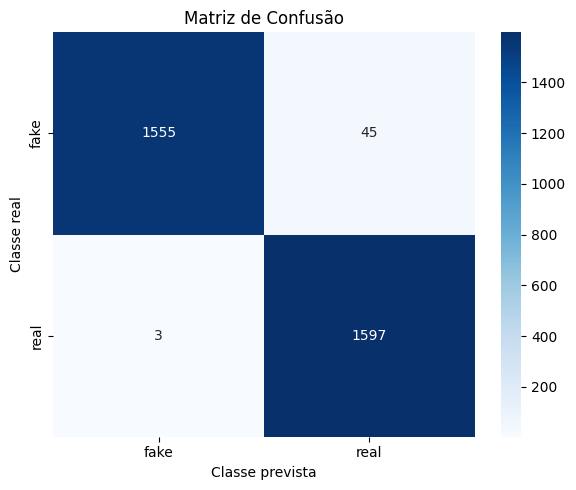

In [10]:
# ======================================================
# Avaliação no conjunto de teste
# ======================================================

rotulos_reais = []
rotulos_previstos = []

model.eval()

with torch.no_grad():

    for imagens, rotulos in loader_teste:

        imagens = imagens.to(device, non_blocking=True)

        saidas = model(imagens)

        previstos = torch.argmax(saidas, dim=1)

        rotulos_reais.extend(rotulos.tolist())
        rotulos_previstos.extend(previstos.cpu().tolist())

# ======================================================
# Relatório
# ======================================================

print(
    classification_report(
        rotulos_reais,
        rotulos_previstos,
        target_names=dataset.dataset.classes,
        digits=4
    )
)

# ======================================================
# Matriz de confusão
# ======================================================

matriz_confusao = confusion_matrix(
    rotulos_reais,
    rotulos_previstos
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_confusao,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.dataset.classes,
    yticklabels=dataset.dataset.classes
)

plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão")

plt.tight_layout()
plt.show()

In [12]:
# ======================================================
# Salvar modelo treinado
# ======================================================

PASTA_MODELOS = "../models"
NOME_MODELO = "resnet50_rgb_512.pth"

os.makedirs(PASTA_MODELOS, exist_ok=True)

CAMINHO_MODELO = os.path.join(
    PASTA_MODELOS,
    NOME_MODELO
)

torch.save(
    model.state_dict(),
    CAMINHO_MODELO
)

print(f"Modelo salvo em: {CAMINHO_MODELO}")

Modelo salvo em: ../models/resnet50_rgb_512.pth
